# Prepare street network for routing analysis

This notebook prepares the street network used for analysing routes to schools.

The network is derived from OpenStreetMap data and will later be used to compute routes and accessibility between homes and schools.

## Load the libraries needed for network preparation

Here we import the libraries needed to load spatial layers, work with OpenStreetMap data, and visualize the network.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

## Load the official school district polygons

Here we load the official district polygons that define the study area.

These polygons will be merged into one municipality-wide boundary and used to download the street network.

In [2]:
schools = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="schools"
)

districts = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="school_districts"
)

In [3]:
districts.head()

,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,kommunekod,...,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1,geometry
0,5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724468.727 6174207.618, 724824.483 6..."
1,5710,t_5710_born_skole_dis_t,caec40da-f997-11ea-8efa-06d09fa510f4,4af9587a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((723566.615 6172586.107, 723670..."
2,5710,t_5710_born_skole_dis_t,caf771da-f997-11ea-8f2a-06d09fa510f4,4afad1e6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724798.236 6169075.917, 724761.682 6..."
3,5710,t_5710_born_skole_dis_t,cae99b50-f997-11ea-8eca-06d09fa510f4,4afbefd6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((723570.181 6175053.926, 723568.928 6..."
4,5710,t_5710_born_skole_dis_t,caf6d3e2-f997-11ea-8f20-06d09fa510f4,4afd1a5a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724592.495 6177975.285, 724787.236 6..."


## Merge the district polygons into one study area

Here we combine all school district polygons into one geometry representing the overall study area.

This boundary will be used to request the bike network from OpenStreetMap.

In [4]:
study_area = districts.dissolve()
study_area

/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:426: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


,geometry,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,"MULTIPOLYGON (((721535.268 6171337.076, 720874...",5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Convert the study area to WGS84

OSMnx expects the boundary geometry in latitude/longitude coordinates.

Here we convert the study area to EPSG:4326 before downloading the network.

In [5]:
study_area_wgs84 = study_area.to_crs(4326)

In [6]:
study_area_wgs84

,geometry,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,"MULTIPOLYGON (((12.52000 55.63733, 12.50923 55...",5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Extract the polygon geometry

The dissolved study area is stored as a GeoDataFrame. Here we extract the polygon geometry itself so it can be used directly in OSMnx.

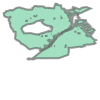

In [7]:
polygon = study_area_wgs84.geometry.iloc[0]
polygon

## Download the bike network within the study area

Here we download the bike network from OpenStreetMap using the study area polygon rather than a place name.

In [8]:
G = ox.graph_from_polygon(
    polygon,
    network_type="bike"
)

/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/

## Check the size of the network

In [9]:
len(G.nodes), len(G.edges)

(22298, 54080)

## Plot the downloaded bike network

Here we make a quick plot of the network to visually check whether it looks like a realistic street network for Copenhagen.

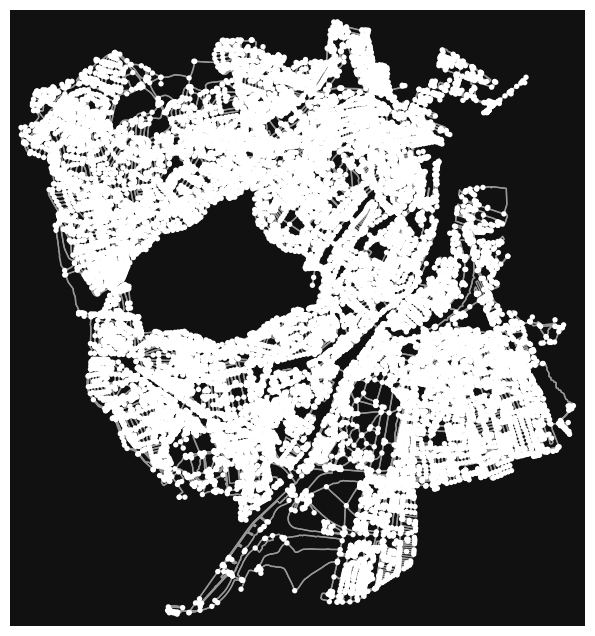

In [10]:
fig, ax = ox.plot_graph(G)

## Convert the graph into GeoDataFrames

Here we convert the network graph into node and edge GeoDataFrames so the road segments can be plotted together with schools and districts.

In [11]:
nodes, edges = ox.graph_to_gdfs(G)

## Reproject the network to the common project CRS

The schools and district polygons are already stored in EPSG:25832.

Here we convert the network layers to the same CRS so they can be overlaid directly.

In [12]:
edges = edges.to_crs(25832)
nodes = nodes.to_crs(25832)

## Plot the network together with districts and schools

This map is used as a visual sanity check to confirm that the road network, school district polygons, and school locations line up correctly.

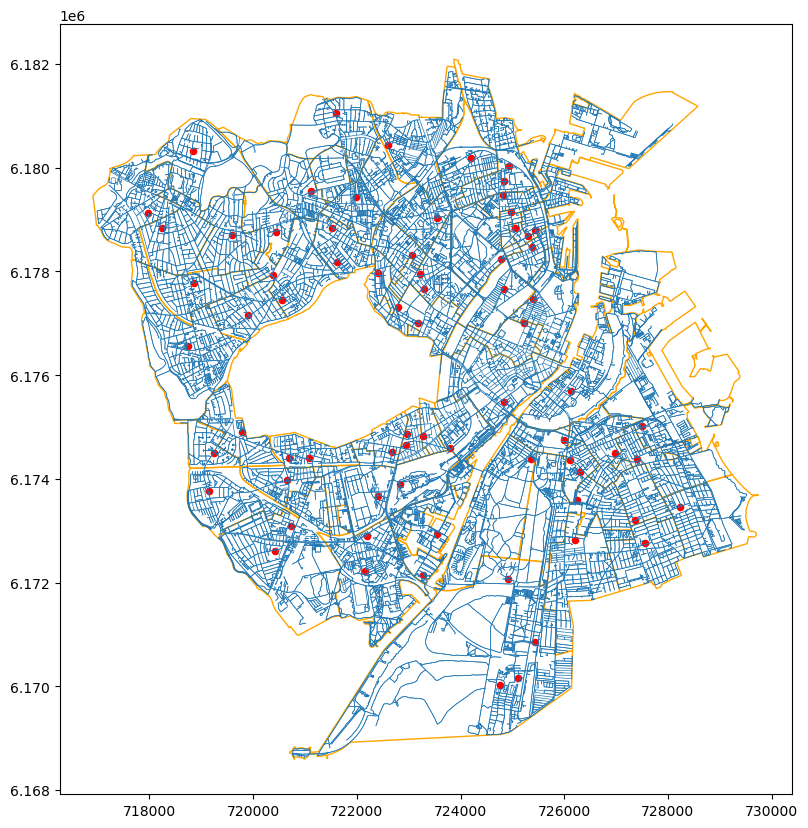

In [13]:
ax = edges.plot(figsize=(10, 10), linewidth=0.5)
districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.show()

## Save the prepared network

Finally I save the downloaded bike network so it can be reused later without downloading it again.

In [14]:
ox.save_graphml(G, "../data/processed/cph_bike_network.graphml")

In [15]:
for col in edges.columns:
    if edges[col].apply(lambda x: isinstance(x, list)).any():
        edges[col] = edges[col].astype(str)

In [16]:
edges.to_file(
    "../data/processed/network_layers.gpkg",
    layer="bike_edges",
    driver="GPKG"
)